Running on: cuda

Loading DCGAN...
Average network found !


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


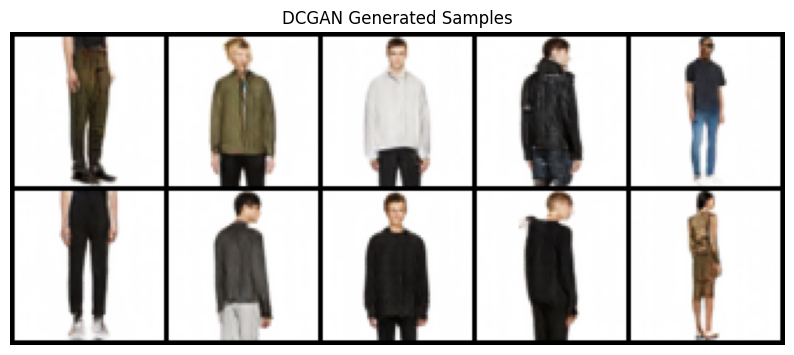

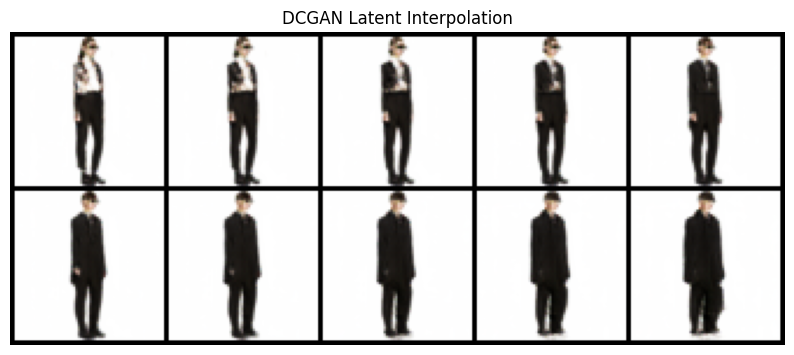


Loading PGAN (Progressive GAN)...
Error loading/running PGAN: betas must be either both floats or both Tensors


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import os
import ssl
import collections
import collections.abc

if not hasattr(collections, 'Iterable'):
    collections.Iterable = collections.abc.Iterable

ssl._create_default_https_context = ssl._create_unverified_context

os.makedirs("lab8_results", exist_ok=True)

# Display images
def show_images(images, title, filename):
    images = images.detach().cpu()
    grid = make_grid(images, nrow=5, normalize=True)

    plt.figure(figsize=(10,6))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.title(title)
    plt.axis("off")

    plt.savefig(f"lab8_results/{filename}")
    plt.show()

# ---------------------------
# Interpolation
# ---------------------------
def interpolate(z1, z2, steps=10):
    alpha = torch.linspace(0, 1, steps)
    vectors = []

    for a in alpha:
        v = (1 - a) * z1 + a * z2
        vectors.append(v)

    return torch.stack(vectors)

# ---------------------------
# Main program
# ---------------------------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Running on:", device)

    # ---------------- DCGAN ----------------
    print("\nLoading DCGAN...")
    try:
        dcgan = torch.hub.load(
            "facebookresearch/pytorch_GAN_zoo:hub",
            "DCGAN",
            dataset_name="celebA",
            pretrained=True,
            useGPU=(device == "cuda")
        )

        noise, _ = dcgan.buildNoiseData(10)
        noise = noise.to(device)

        with torch.no_grad():
            dcgan_images = dcgan.test(noise)

        show_images(dcgan_images,
                    "DCGAN Generated Samples",
                    "dcgan_samples.png")

        # DCGAN interpolation
        z1, _ = dcgan.buildNoiseData(1)
        z2, _ = dcgan.buildNoiseData(1)
        interp = interpolate(z1[0], z2[0], 10).to(device)

        with torch.no_grad():
            interp_images = dcgan.test(interp)

        show_images(interp_images,
                    "DCGAN Latent Interpolation",
                    "dcgan_interpolation.png")

    except Exception as e:
        print(f"Error loading/running DCGAN: {e}")

    # ---------------- PGAN (Replacing StyleGAN2) ----------------
    print("\nLoading PGAN (Progressive GAN)...")
    try:
        # PGAN used here because pytorch_GAN_zoo does not have StyleGAN2
        pgan = torch.hub.load(
            "facebookresearch/pytorch_GAN_zoo:hub",
            "PGAN",
            model_name="celebaHQ-256", # Using lowercase 'a' to avoid repo errors
            pretrained=True,
            useGPU=(device == "cuda")
        )

        noise, _ = pgan.buildNoiseData(10)
        noise = noise.to(device)

        with torch.no_grad():
            pgan_images = pgan.test(noise)

        show_images(pgan_images,
                    "PGAN Generated Samples",
                    "pgan_samples.png")

        # PGAN interpolation
        z1, _ = pgan.buildNoiseData(1)
        z2, _ = pgan.buildNoiseData(1)
        interp = interpolate(z1[0], z2[0], 10).to(device)

        with torch.no_grad():
            interp_images = pgan.test(interp)

        show_images(interp_images,
                    "PGAN Latent Interpolation",
                    "pgan_interpolation.png")

    except Exception as e:
        print(f"Error loading/running PGAN: {e}")

if __name__ == "__main__":
    main()